In [57]:
import numpy as np
import h5py
from matplotlib import pyplot as plt

f1 = h5py.File('pSEOBNR_waveforms.hdf', 'r')

f1['hc'][()].shape


(1000, 4096)

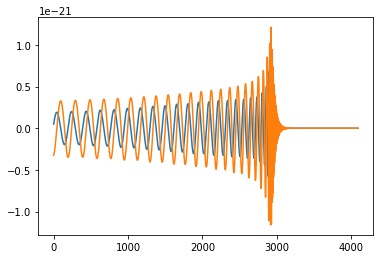

In [58]:
plt.plot(f1['hc'][0])
plt.plot(f1['hp'][0])


In [59]:
from ml4gw.gw import get_ifo_geometry, compute_observed_strain
from ml4gw.distributions import PowerLaw, Sine, Cosine, DeltaFunction
import torch
from torch.distributions import Uniform

# Define probability distributions for uniform sky location and polarization angle
dec = Cosine()
psi = Uniform(0, torch.pi)
phi = Uniform(-torch.pi, torch.pi)
device = 'cpu'
sample_rate = 4096

ifos = ["H1", "L1"]
tensors, vertices = get_ifo_geometry(*ifos)

num_waveforms = f1['hc'][()].shape[0]

# Pass the detector geometry, along with the polarizations and sky parameters,
# to get the observed strain
waveforms = compute_observed_strain(
    dec=dec.sample((num_waveforms,)).to(device),
    psi=psi.sample((num_waveforms,)).to(device),
    phi=phi.sample((num_waveforms,)).to(device),
    detector_tensors=tensors.to(device),
    detector_vertices=vertices.to(device),
    sample_rate=sample_rate,
    cross=torch.Tensor(f1['hc'][()]),
    plus=torch.Tensor(f1['hp'][()]),
)
print(waveforms.shape)


torch.Size([1000, 2, 4096])


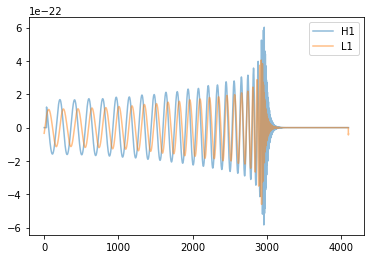

In [60]:
plt.plot(waveforms[0, 0].cpu(), label="H1", alpha=0.5)
plt.plot(waveforms[0, 1].cpu(), label="L1", alpha=0.5)
plt.legend()


In [61]:
from ml4gw.transforms import SpectralDensity
import h5py

fftlength = 2
spectral_density = SpectralDensity(
    sample_rate=sample_rate,
    fftlength=fftlength,
    overlap=None,
    average="median",
).to(device)


# This is H1 and L1 data from O3 that I downloaded earlier
# We have tools for dataloading that I'll get to later
background_file = "/data/p_dsi/ligo/chattec-dgx01/chattec/LIGO/ligo_data/ml4gw_data_test/background-1240658942-9110.hdf5"
with h5py.File(background_file, "r") as f:
    background = [torch.Tensor(f[ifo][:]) for ifo in ifos]
    background = torch.stack(background).to(device)

# Note cast to double
psd = spectral_density(background.double())
print(psd.shape)


torch.Size([2, 4097])


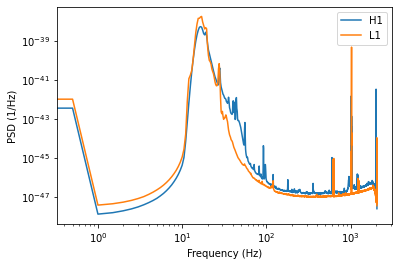

In [62]:
# Desired duration of time-domain waveform
waveform_duration = 1
# Sample rate of all the data we'll be using today
sample_rate = 4096

# Define minimum, maximum, and reference frequencies
f_min = 20
f_max = 512
f_ref = 20

nyquist = sample_rate / 2
num_samples = int(waveform_duration * sample_rate)
num_freqs = num_samples // 2 + 1

# Create an array of frequency values at which to generate our waveform
# At the moment, only frequency-domain approximants have been implemented
frequencies = torch.linspace(0, nyquist, num_freqs).to(device)
freq_mask = (frequencies >= f_min) * (frequencies < f_max).to(device)



freqs = torch.linspace(0, nyquist, psd.shape[-1])
plt.plot(freqs, psd.cpu()[0], label="H1")
plt.plot(freqs, psd.cpu()[1], label="L1")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (1/Hz)")
plt.legend()
plt.show()


In [63]:
from ml4gw.gw import compute_ifo_snr, compute_network_snr

# Note need to interpolate
if psd.shape[-1] != num_freqs:
    # Adding dummy dimensions for consistency
    while psd.ndim < 3:
        psd = psd[None]
    psd = torch.nn.functional.interpolate(
        psd, size=(num_freqs,), mode="linear"
    )

# We can compute both the individual and network SNRs
# The SNR calculation starts at the minimum frequency we
# specified earlier and goes to the maximum
# TODO: There's probably no reason to have multiple functions
h1_snr = compute_ifo_snr(
    responses=waveforms[:, 0],
    psd=psd[:, 0],
    sample_rate=sample_rate,
    highpass=f_min,
)
l1_snr = compute_ifo_snr(
    responses=waveforms[:, 1],
    psd=psd[:, 1],
    sample_rate=sample_rate,
    highpass=f_min,
)
network_snr = compute_network_snr(
    responses=waveforms,
    psd=psd,
    sample_rate=sample_rate,
    highpass=f_min
)


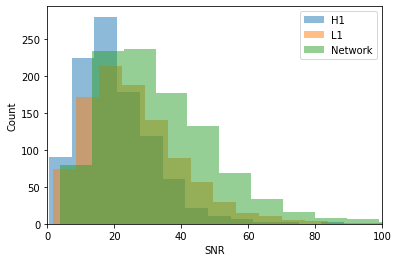

In [64]:
plt.hist(h1_snr.cpu(), bins=25, alpha=0.5, label="H1")
plt.hist(l1_snr.cpu(), bins=25, alpha=0.5, label="L1")
plt.hist(network_snr.cpu(), bins=25, alpha=0.5, label="Network")
plt.xlabel("SNR")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.legend()
plt.show()


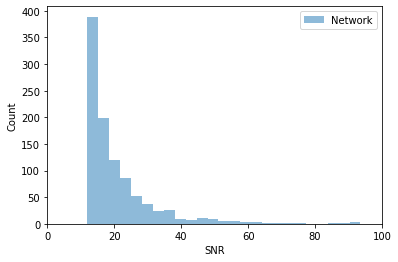

In [65]:
from ml4gw.gw import reweight_snrs

target_snrs = PowerLaw(12, 100, -3).sample((num_waveforms,)).to(device)
# Each waveform will be scaled by the ratio of its target SNR to its current SNR
waveforms = reweight_snrs(
    responses=waveforms,
    target_snrs=target_snrs,
    psd=psd,
    sample_rate=sample_rate,
    highpass=f_min
)

network_snr = compute_network_snr(
    responses=waveforms,
    psd=psd,
    sample_rate=sample_rate,
    highpass=f_min
)

plt.hist(network_snr.cpu(), bins=25, alpha=0.5, label="Network")
plt.xlabel("SNR")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.legend()
plt.show()


In [66]:
from ml4gw.dataloading import Hdf5TimeSeriesDataset
from pathlib import Path

# Defining some parameters for future use, and to 
# determine the size of the windows to sample.
# We're going to be whitening the last part of each
# window with a PSD calculated from the first part,
# so we need to grab enough data to do that

# Length of data used to estimate PSD
psd_length = 16
psd_size = int(psd_length * sample_rate)

# Length of filter. A segment of length fduration / 2
# will be cropped from either side after whitening
fduration = 2

# Length of window of data we'll feed to our network
kernel_length = 0.06
kernel_size = int(0.06 * sample_rate)

# Total length of data to sample
window_length = psd_length + fduration + kernel_length

fnames = list(Path("/data/p_dsi/ligo/chattec-dgx01/chattec/LIGO/ligo_data/ml4gw_data").iterdir())
dataloader = Hdf5TimeSeriesDataset(
    fnames=fnames,
    channels=ifos,
    kernel_size=int(window_length * sample_rate),
    batch_size=2 * num_waveforms, # Grab twice as many background samples as we have waveforms
    batches_per_epoch=1, # Just doing 1 here for demonstration purposes
    coincident=False,
)

background_samples = [x for x in dataloader][0].to(device)
print(background_samples.shape)


torch.Size([2000, 2, 73973])


In [71]:
window_length

18.06

In [72]:
from ml4gw.transforms import Whiten

whiten = Whiten(
    fduration=fduration,
    sample_rate=sample_rate,
    highpass=f_min
).to(device)

window_size = kernel_size + int(fduration * sample_rate)

def sample_waveforms(responses: torch.Tensor) -> torch.Tensor:
    responses = responses[:, :, -window_size:]
    pad = [0, int(window_size // 2)]
    responses = torch.nn.functional.pad(responses, pad)
    from ml4gw.utils.slicing import sample_kernels
    return sample_kernels(responses, window_size, coincident=True)

# Create PSDs using the first psd_length seconds of each sample
# with the SpectralDensity module we defined earlier
psd = spectral_density(background_samples[..., :psd_size].double())
print(f"PSD shape: {psd.shape}")

# Take everything after the first psd_length as our input kernel
kernel = background_samples[..., psd_size:]
# And whiten using our PSDs
whitened_kernel = whiten(kernel, psd)

responses_sampled = sample_waveforms(waveforms)

whitened_waveforms = whiten(responses_sampled, psd)

print(f"Kernel shape: {kernel.shape}")
print(f"Whitened kernel shape: {whitened_kernel.shape}")
print(f"Whitened waveforms shape: {whitened_waveforms.shape}")


PSD shape: torch.Size([2000, 2, 4097])


ValueError: Can't sample kernels of size 8437 from tensor with shape torch.Size([1000, 2, 8314])

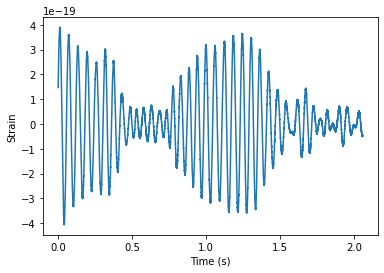

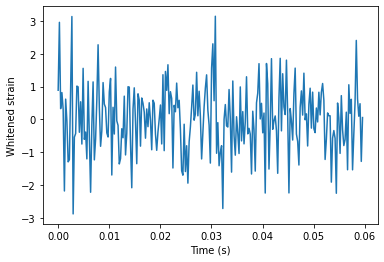

In [56]:
times = torch.arange(0, kernel_length + fduration, 1 / sample_rate)
plt.plot(times[:8437], kernel[0, 0].cpu())
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.show()

times = torch.arange(0, kernel_length, 1 / sample_rate)
plt.plot(times[:245], whitened_kernel[0, 0].cpu())
plt.xlabel("Time (s)")
plt.ylabel("Whitened strain")
plt.show()
